Name :- Mohini Deshmukh

Roll No. :- 76

PRN :- 2425010071

Course :- Deep Learning Laboratory

Class :- TY Data Science


In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


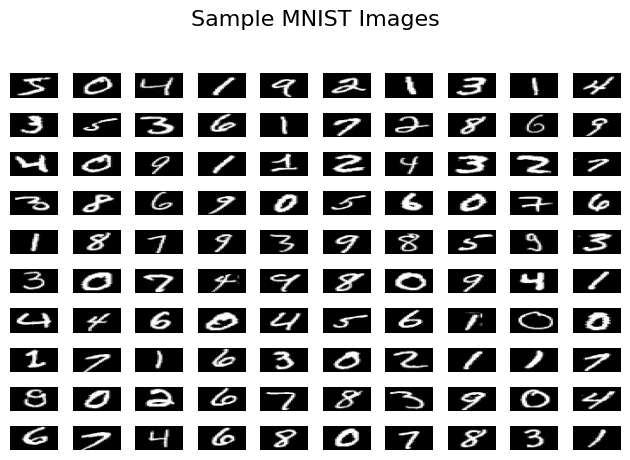

In [6]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto', cmap='gray') # Added cmap='gray' for better visualization
        ax[i][j].axis('off') # Turn off axes for cleaner image display
        k += 1
plt.suptitle('Sample MNIST Images', fontsize=16) # Add a title for the entire figure
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for the suptitle
plt.show()

In [8]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
history = model.fit(x_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9189 - loss: 0.2856 - val_accuracy: 0.9526 - val_loss: 0.1591
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9622 - loss: 0.1288 - val_accuracy: 0.9642 - val_loss: 0.1253
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9741 - loss: 0.0888 - val_accuracy: 0.9680 - val_loss: 0.1076
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9798 - loss: 0.0673 - val_accuracy: 0.9714 - val_loss: 0.0963
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9848 - loss: 0.0505 - val_accuracy: 0.9745 - val_loss: 0.0874
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9882 - loss: 0.0404 - val_accuracy: 0.9733 - val_loss: 0.0921
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9904 - loss: 0.0317 - val_accuracy: 0.9746 - val_loss: 0.0928
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9927 - loss: 0.0241 -

In [18]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.9774 - loss: 0.0813
Test Loss: 0.0813
Test Accuracy: 0.9774


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


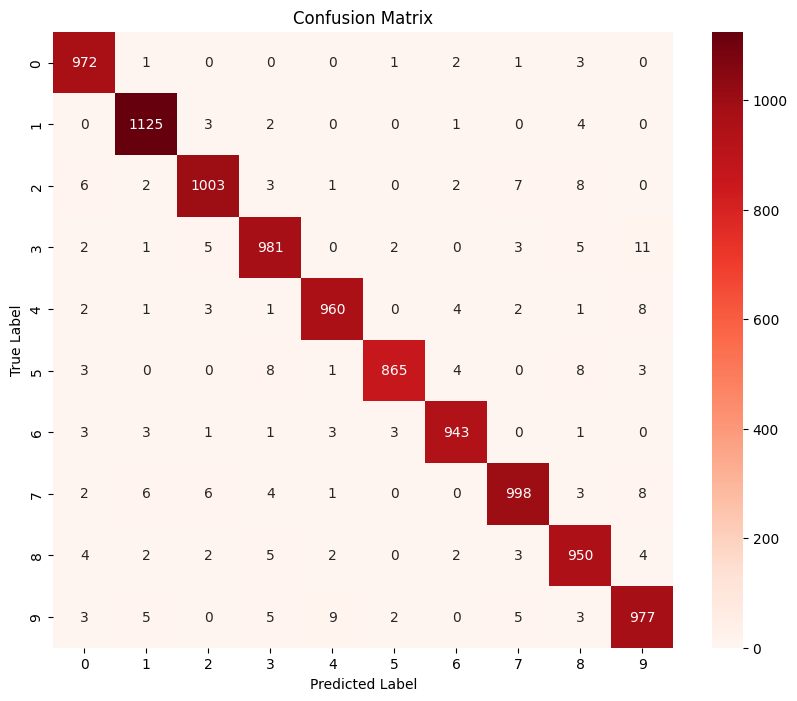

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = np.argmax(model.predict(x_test), axis=-1)
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()